# 3.7. Weight Decay
D2L의 Weight Decay장을 PyTorch 기준으로 정리함.

앞장에서 overfitting은 training data를 외워버릴 수 있다고 했다.
weight Decay는 이런 overfitting을 줄이기 위해 사용한다. 

## 0. 기본 설정

PyTorch를 불러오고 현재 환경을 확인

In [2]:
%matplotlib inline
import random
import torch
import matplotlib.pyplot as plt
from torch.distributions.multinomial import Multinomial
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

torch.manual_seed(0)
random.seed(0)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu128


## 1. 기존 선형회귀 loss

선형회귀 모델은 다음과 같다.

$$
\hat{y} = w^T x + b
$$

여기서:

* $x$ : 입력 feature
* $w$ : weight, 가중치
* $b$ : bias, 편향
* $\hat{y}$ : 모델 예측값
* $y$ : 실제 정답 label

기존 선형회귀의 loss는 다음과 같다.

$$
L(w, b) =
\frac{1}{n}
\sum_{i=1}^{n}
\frac{1}{2}
\left(w^T x^{(i)} + b - y^{(i)}\right)^2
$$

이 loss는 모델 예측값과 정답의 차이를 줄이는 역할을 한다.
예측값 $\hat{y}$가 정답 $y$와 비슷해지도록 $w$, $b$를 학습한다.

## 2. overfitting은 왜 생기는가

training data는 적은데 feature가 많을 때 생긴다.

예를 들어서 feature가 200개인데, training data가 20개라고 했을때
$$
w_1x_1 + w_2x_2 + \cdots + w_{200}x_{200} + b
$$
여기에서 모델은 200개의 weight를 조정할 수 있다. 근데 training data가 20개 밖에 없으니 모델 입장에서는 자유도가 너무 많다.

이런 상황에서는 모델이 실제 규칙을 배우는게 아니고, training data 20개에만 맞는 이상한 weight 조합을 찾을 수 있다. 이런걸 overfitting이라고 한다.

## 3. Weight Decay의 핵심 아이디어

Weight decay는 기존 loss에 weight 크기 벌점을 추가한다.

기존 loss는 다음과 같았다.

$$
L(w, b)
$$

Weight decay를 적용하면 다음처럼 바뀐다.

$$
L(w, b) + \frac{\lambda}{2}|w|^2
$$

여기서 새로 추가된 부분은 다음이다.

$$
\frac{\lambda}{2}|w|^2
$$

이 항은 weight가 커질수록 loss를 증가시킨다.

정답을 맞추는 것도 중요하지만, weight를 너무 크게 만들면 안좋게 하는 것이다.

## 4. $|w|^2$는 무엇인가?

$w$가 다음과 같다고 해보자.

$$
w =
\begin{bmatrix}
w_1 \\
w_2 \\
w_3 \\
\vdots \\
w_d
\end{bmatrix}
$$

그러면 $|w|^2$는 다음과 같다.
$$
w_1^2 + w_2^2 + w_3^2 + \cdots + w_d^2
$$
 
모든 weight를 제곱해서 더한 값이다. D2L에서는 이것을 다음처럼 사용한다.  
$$
\frac{1}{2}
\left(
w_1^2 + w_2^2 + \cdots + w_d^2
\right)
$$

PyTorch로 쓰면 다음과 같다.
```py
def l2_penalty(w):
    return (w ** 2).sum() / 2
```

## 5. 왜 weight가 크면 문제가 되는가?

선형회귀 모델을 다시 보자.
$$
w_1x_1 + w_2x_2 + \cdots + w_dx_d + b
$$

여기서 어떤 weight가 너무 크면, 그 feature가 조금만 변해도 예측값이 크게 변한다.

예를 들어서 $w_3$가 매우 크다고 해보자.

$$
w_3 = 100
$$

그러면 $x_3$가 조금만 변해도 예측값이 크게 변한다. 모델이 특정 feature에 너무 민감하다는 뜻이다.

training data 안에서는 잘 맞을 수 있다. 그런데 새로운 data에서는 예측이 쉽게 망가질 수 있다. 그래서 weight decay는 weight가 너무 커지는 것을 막는다.

## 6. $\lambda$는 무엇인가?

Weight decay가 적용된 loss는 다음과 같다.

$$
L(w, b) + \frac{\lambda}{2}|w|^2
$$

여기서 $\lambda$는 regularization strength이다. weight 크기에 대한 벌점을 얼마나 강하게 줄지 정하는 값이다.

$\lambda = 0$인 경우
$$
L(w, b)
$$

이 경우에 weight decay가 없는 거랑 같다.

$\lambda$가 작은 경우
weight 크기에 대한 벌점이 약하다.
모델이 weight를 비교적 자유롭게 키울 수 있다.

$\lambda$가 큰 경우
weight 크기에 대한 벌점이 강하다.
모델이 weight를 크게 만들기 어렵다.

하지만 $\lambda$가 너무 크면 문제가 생긴다.
모델이 weight를 거의 사용하지 못해서 underfitting이 생길 수 있다.

정리하면 다음과 같다.

$$
\lambda \text{가 너무 작음}
\Rightarrow
\text{overfitting을 못 막을 수 있음}
$$

$$
\lambda \text{가 너무 큼}
\Rightarrow
\text{underfitting이 생길 수 있음}
$$

## 7. 왜 이름이 Weight Decay인가?

Weight decay가 들어가면 weight update 식은 다음과 비슷해진다.
$$
\eta \nabla_w L(w, b)
$$

여기서:

$\eta$ : learning rate  
$\lambda$ : weight decay strength  
$\nabla_w L(w, b)$ : 기존 loss에 대한 gradient  

$$
(1 - \eta \lambda)w
$$

이 항은 기존 weight를 조금 줄이는 역할을 한다.
예를 들어 다음과 같다고 하자.

$$
\eta = 0.01
$$

$$
\lambda = 3
$$

그러면:
$$
1 - 0.01 \times 3 = 0.97
$$

따라서 weight는 매 step마다 이런 식으로 줄어드는 압력을 받는다.

$$
w \leftarrow (1 - \eta \lambda)w - \eta \nabla_w L(w, b)
$$

그래서 이름이 weight decay라고 한다.

weight가 decay, 즉 조금씩 감소하는 방향으로 압력을 받기 때문이다.

weight decay는 weight를 무조건 0으로 만드는 것이 아니다.
$$
\text{예측 오차를 줄이는 힘}
+
\text{weight를 작게 만드는 힘}
$$

그래서 필요한 weight는 남고, 커지는 weight는 억제된다.

## 8. L2 Regularization

Weight decay에서 자주 사용하는 방식은 L2 regularization이다.

L2 penalty는 다음과 같다.
$$
w_1^2 + w_2^2 + \cdots + w_d^2
$$

loss에 추가하면 다음과 같다.

$$
L(w, b) + \frac{\lambda}{2}\left(w_1^2 + w_2^2 + \cdots + w_d^2\right)
$$

L2 regularization은 weight를 제곱하기 때문에 큰 weight를 강하게 벌준다.  
예를 들어서:

$$
2^2 = 4
$$

$$
10^2 = 100
$$

weight가 커질수록 패널티가 빠르게 커진다.  
L2 regularization은 weight가 너무 커지지 못하게 막는다.

## 9. L1 Regularization과 L2 Regularization 차이

regularization에는 L2만 있는게 아니고 L1도 있다.

L1
$$
|w|_1 = |w_1| + |w_2| + \cdots + |w_d|
$$

L2
$$
|w|^2 = w_1^2 + w_2^2 + \cdots + w_d^2
$$

차이는 이렇다.
| 구분 | 수식 | 특징 |
| --- | --- | --- |
| L1 | $\sum_i |w_i|$ | 일부 weight를 0에 가깝게 만든다 |
| L2 | $\sum_i w_i^2$ | weight 전체를 작게 만든다 |

L1은 중요하지 않은 feature의 weight를 0에 가깝게 만들 수 있다.
그래서 feature selection 효과가 있다.

L2는 weight를 전체적으로 작게 만든다.
특정 feature 하나에 너무 강하게 의존하지 못하게 만든다.

Weight decay는 보통 L2 regularization을 의미한다고 한다.

## 10. D2L 실험 구조

D2L은 일부러 overfitting이 잘 생기는 상황을 만든다.


설정은 다음과 같다.


```py
num_train = 20
num_val = 100
num_inputs = 200
```


즉:


$$
\text{training samples} = 20
$$


$$
\text{validation samples} = 100
$$


$$
\text{number of features} = 200
$$


feature는 200개인데 training data는 20개뿐이다.


모델 입장에서는 20개의 data만 보고 200개의 weight를 맞춰야 한다.
그래서 training data를 외우기 쉽다.


데이터 생성식은 다음과 비슷하다.


$$
y
=
0.05
+
\sum_{i=1}^{d} 0.01x_i
+
\epsilon
$$


여기서:


* $d = 200$
* 실제 weight는 모두 $0.01$
* 실제 bias는 $0.05$
* $\epsilon$은 noise


noise는 다음과 같은 정규분포에서 나온다.


$$
\epsilon \sim \mathcal{N}(0, 0.01^2)
$$

In [3]:
from torch.utils.data import TensorDataset, DataLoader

def make_data(num_train=20, num_val=100, num_inputs=200, batch_size=5):
    n = num_train + num_val

    X = torch.randn(n, num_inputs)

    true_w = torch.ones((num_inputs, 1)) * 0.01
    true_b = 0.05

    noise = torch.randn(n, 1) * 0.01
    y = X @ true_w + true_b + noise

    train_ds = TensorDataset(X[:num_train], y[:num_train])
    val_ds = TensorDataset(X[num_train:], y[num_train:])

    train_iter = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_iter = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    return train_iter, val_iter

train_iter, val_iter = make_data()

for X_batch, y_batch in train_iter:
    print("X_batch shape:", X_batch.shape)
    print("y_batch shape:", y_batch.shape)
    break

X_batch shape: torch.Size([5, 200])
y_batch shape: torch.Size([5, 1])


## 11. 데이터 shape 확인

위 코드에서 한 minibatch의 shape는 이렇다

$$
X \in \mathbb{R}^{5 \times 200}
$$

$$
y \in \mathbb{R}^{5 \times 1}
$$

배치 사이즈가 5라서 한번에 5개의 sample을 가져온다. feature 수는 200개라 $X$의 shape는 [5, 200]이 된다. 모델이 weight는 다음 shape를 가져야한다.

$$
w \in \mathbb{R}^{200 \times 1}
$$

그러면 행렬곱 결과는 다음과 같다.

$$
Xw \in \mathbb{R}^{5 \times 1}
$$

sample마다 예측값 하나가 나온다.

## 12. L2 penalty 함수

L2 penalty는 다음 수식을 코드로 구현한 것이다.

$$
\frac{1}{2}|w|^2 = \frac{1}{2}\sum_{i=1}^{d} w_i^2
$$

In [4]:
def l2_penalty(w):
    return (w ** 2).sum() / 2

w_test = torch.tensor([[1.0], [2.0], [3.0]])
print(l2_penalty(w_test))

tensor(7.)


## 13. 평가 함수

training 중에는 weight decay penalty를 loss에 추가한다. 평가할 떄는 penalty를 빼고 예측이 얼마나 틀렸는지만 본다.

평가 loss는 이렇게 사용한다.
$$
\frac{1}{n}\sum_{i=1}^{n}\frac{1}{2}(\hat{y}^{(i)} - y^{(i)})^2
$$

In [6]:
def squared_loss(y_hat, y):
    return ((y_hat - y) ** 2 / 2).mean()

def evaluate_loss(w, b, data_iter):
    total_loss = 0.0
    total_count = 0

    with torch.no_grad():
        for X, y in data_iter:
            y_hat = X @ w + b
            loss = squared_loss(y_hat, y)

            batch_size = X.shape[0]
            total_loss += loss.item() * batch_size
            total_count += batch_size

    return total_loss / total_count

## 14. Weight Decay 직접 구현

먼저 PyTorch optimizer의 weight_decay 옵션 쓰지않고 직접 구현 해보자.

loss에 다음 항을 더해준다
$$
\lambda \cdot \frac{1}{2}|w|^2
$$

bias $b$에는 penalty를 주지 않는다. bias는 feature의 민감도를 키우는 것보다 전체 예측값을 평행이동해주는 역할에 가깝기 때문이다.

In [12]:
def train_scratch(lambd, lr=0.01, num_epochs=100):
    torch.manual_seed(0)

    num_inputs = 200

    # 중요:
    # torch.randn(..., requires_grad=True) * 0.01 로 쓰면 w가 leaf tensor가 아니게 된다.
    # 그래서 먼저 값을 만든 뒤 requires_grad_()를 켠다.
    w = torch.randn((num_inputs, 1)) * 0.01
    w.requires_grad_(True)

    b = torch.zeros(1, requires_grad=True)

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        for X, y in train_iter:
            y_hat = X @ w + b

            data_loss = squared_loss(y_hat, y)
            penalty = lambd * l2_penalty(w)
            loss = data_loss + penalty

            loss.backward()

            with torch.no_grad():
                w -= lr * w.grad
                b -= lr * b.grad

                w.grad.zero_()
                b.grad.zero_()

        train_loss = evaluate_loss(w, b, train_iter)
        val_loss = evaluate_loss(w, b, val_iter)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    print(f"lambda = {lambd}")
    print("final train loss:", train_losses[-1])
    print("final val loss:", val_losses[-1])
    print("L2 penalty of w:", l2_penalty(w).item())

    return train_losses, val_losses, w, b

## 15. Weight Decay 없이 학습하기

먼저 $\lambda = 0$으로 둔다. loss는 기존 선형회귀 loss랑 같다.

feature는 200개인데 trainingdata는 20개뿐이라 training loss는 낮아질 수 있다. 하지만 validation loss는 상대적으로 높게 나올 가능성이 크다.

In [15]:
train_losses_0, val_losses_0, w_0, b_0 = train_scratch(lambd=0)
train_losses_3, val_losses_3, w_3, b_3 = train_scratch(lambd=3)

lambda = 0
final train loss: 3.131175891715725e-17
final val loss: 0.01153313412796706
L2 penalty of w: 0.0015569040551781654
lambda = 3
final train loss: 0.0003090040590905119
final val loss: 0.00886340900324285
L2 penalty of w: 0.0005488201859407127


## 17. 비교하기

* $\lambda = 0$ : weight decay 없음
* $\lambda = 3$ : weight decay 있음

단순히 training loss가 낮은게 좋은 결과는 아니다. validation loss가 낮아야 새로운 데이터에서도 잘 맞는 모델이라고 볼 수 있다.

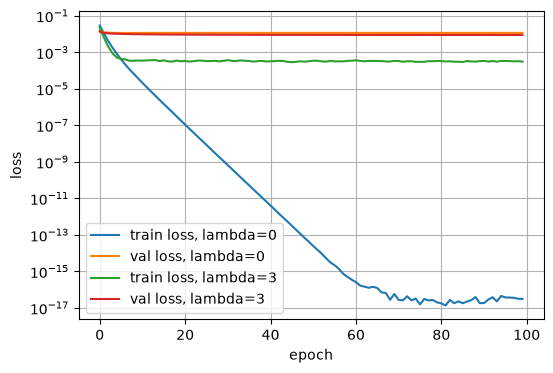

In [16]:
plt.figure(figsize=(6, 4))

plt.plot(train_losses_0, label="train loss, lambda=0")
plt.plot(val_losses_0, label="val loss, lambda=0")
plt.plot(train_losses_3, label="train loss, lambda=3")
plt.plot(val_losses_3, label="val loss, lambda=3")

plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

## 18. 결과

Weight decay가 없으면 모델은 training data에 잘 맞으려 한다. 이때 training loss는 작아질 수 있지만 validation loss는 잘 줄지 않을 수 있다. 이것은 모델이 training data만 외운 overfitting 상황일 수 있다.

Weight decay를 적용하면 weight크기가 작아진다.

그러면 모델이 특정 feature에 크게 의존하지 못한다.

그래서 training loss는 weight decay가 없을 때보다 조금 높을 수 있는데, validation loss는 더 좋아질 수 있다.

$$
\text{training loss만 낮다고 좋은 모델이 아니다}
$$

$$
\text{validation loss가 낮아야 일반화가 잘 된 모델이다}
$$

## 19. PyTorch weight_decay 사용

실제로는 loss에 L2 penalty를 직접 더하지 않고 optimizer에서 weight_decay 옵션을 자주 사용한다고 한다.

다음은 nn.Linear랑 torch.optim.SGD를 사용한다.

weight에는 weight_decay를 적용하고, bias에는 적용하지 않는다.

In [18]:
import torch.nn as nn

def train_concise(wd, lr=0.01, num_epochs=100):
    torch.manual_seed(0)

    net = nn.Linear(200, 1)
    loss_fn = nn.MSELoss(reduction="mean")

    optimizer = torch.optim.SGD([
        {"params": [net.weight], "weight_decay": wd},
        {"params": [net.bias]}
    ], lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        for X, y in train_iter:
            y_hat = net(X)
            loss = loss_fn(y_hat, y) / 2

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_loss = evaluate_loss(net.weight.T, net.bias, train_iter)
        val_loss = evaluate_loss(net.weight.T, net.bias, val_iter)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    print(f"weight_decay = {wd}")
    print("final train loss:", train_losses[-1])
    print("final val loss:", val_losses[-1])
    print("L2 penalty of w:", l2_penalty(net.weight).item())

    return train_losses, val_losses, net

## 20. PyTorch 방식으로 비교하기

weight_decay = 0
final train loss: 4.898859023366609e-16
final val loss: 0.1632963629439473
L2 penalty of w: 0.1300818920135498
weight_decay = 3
final train loss: 0.0003184633096680045
final val loss: 0.008861755370162427
L2 penalty of w: 0.000533945276401937


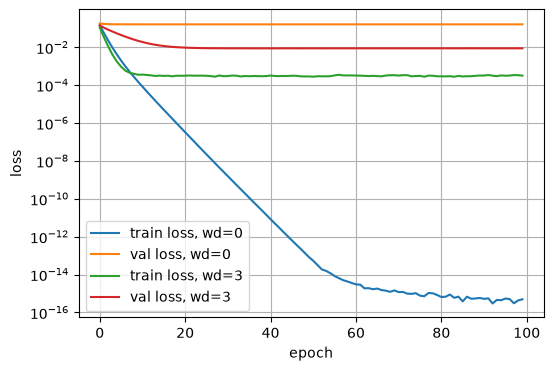

In [20]:
train_losses_wd0, val_losses_wd0, net_wd0 = train_concise(wd=0)
train_losses_wd3, val_losses_wd3, net_wd3 = train_concise(wd=3)

plt.figure(figsize=(6, 4))

plt.plot(train_losses_wd0, label="train loss, wd=0")
plt.plot(val_losses_wd0, label="val loss, wd=0")
plt.plot(train_losses_wd3, label="train loss, wd=3")
plt.plot(val_losses_wd3, label="val loss, wd=3")

plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

## 21. 직접 구현 / PyTorch 구현 차이

직접 구현 방식
```py
loss = data_loss + lambd * l2_penalty(w)
```

PyTorch 구현 방식
```py
optimizer = torch.optim.SGD([
    {"params": [net.weight], "weight_decay": wd},
    {"params": [net.bias]}
], lr=lr)
```

둘다 weight가 너무 커지지 않게 만드는 목적은 똑같다.

그런데 실제 프로젝트에서는 PyTorch optimizer의 weight_decay 옵션을 쓰는게 더 간단하다고 하다.

## 22. 오늘의 정리

- Overfitting은 모델이 training data에만 너무 잘 맞고, 새로운 data에는 약한 상태다.
- feature는 많은데 training data가 적으면 overfitting이 쉽게 생긴다.
- Weight decay는 loss에 weight 크기 penalty를 추가하는 방법이다.
- Weight decay가 적용된 loss는 다음과 같다.

$$
L(w, b) + \frac{\lambda}{2}|w|^2
$$

- $|w|^2$는 모든 weight를 제곱해서 더한 값이다.
- $\lambda$는 weight penalty를 얼마나 강하게 줄지 정하는 hyperparameter다.
- $\lambda = 0$이면 weight decay가 없는 것이다.
- $\lambda$가 너무 작으면 overfitting을 못 막을 수 있다.
- $\lambda$가 너무 크면 underfitting이 생길 수 있다.
- Weight decay는 weight를 무조건 0으로 만드는 것이 아니다.
- 예측 오차를 줄이는 힘과 weight를 작게 만드는 힘 사이에서 균형을 잡는다.
- 보통 bias에는 weight decay를 적용하지 않는다.
- PyTorch에서는 optimizer의 weight_decay 옵션으로 쉽게 적용할 수 있다.